In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visa_df=pd.read_csv(r"C:\Users\B VENKATA SAILAJA\Documents\Datasets_GenAi\Visadataset.csv")
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [4]:
num=visa_df.select_dtypes(exclude='object').columns
cat=visa_df.select_dtypes(include='object').columns

In [5]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [6]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

**Prevailing_wage**

In [29]:
pw=visa_df['prevailing_wage']
ye=visa_df['yr_of_estab']
ne=visa_df['no_of_employees']
print(pw)
print(ye)
print(ne)

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64
0        2007
1        2002
2        2008
3        1897
4        2005
         ... 
25475    2008
25476    2006
25477    1910
25478    1887
25479    1960
Name: yr_of_estab, Length: 25480, dtype: int64
0        14513
1         2412
2        44444
3           98
4         1082
         ...  
25475     2601
25476     3274
25477     1121
25478     1918
25479     3195
Name: no_of_employees, Length: 25480, dtype: int64


In [15]:
mini=min(pw)
maxi=max(pw)
mean=np.mean(pw)
med=np.median(pw)
print(mini,maxi,mean,med)

2.1367 319210.27 74455.81459209183 70308.20999999999


- count
- min
- 25p
- 50p
- mean
- median
- 75p
- max

In [30]:
l=[pw.count(),
   pw.min(),
   pw.max(),
   round(np.percentile(pw,25),2),
   round(pw.mean(),2),
   round(pw.median(),2),
   round(np.percentile(pw,50),2),
   round(np.percentile(pw,75),2)]
M=[ye.count(),
   ye.min(),
   ye.max(),
   round(np.percentile(ye,25),2),
   round(ye.mean(),2),
   round(ye.median(),2),
   round(np.percentile(ye,50),2),
   round(np.percentile(ye,75),2)]
n=[ne.count(),
   ne.min(),
   ne.max(),
   round(np.percentile(ne,25),2),
   round(ne.mean(),2),
   round(ne.median(),2),
   round(np.percentile(ne,50),2),
   round(np.percentile(ne,75),2)]
id=['count','min','max','25p','mean','median','50p','75p']
pd.DataFrame({
    'prevailing_wage': l,
    'yr_of_estab': M,
    'no_of_employees':n
    },
    index=id)


,prevailing_wage,yr_of_estab,no_of_employees
count,25480.0000,25480.00,25480.00
min,2.1367,1800.00,-26.00
max,319210.2700,2016.00,602069.00
25p,34015.4800,1976.00,1022.00
mean,74455.8100,1979.41,5667.04
median,70308.2100,1997.00,2109.00
50p,70308.2100,1997.00,2109.00
75p,107735.5100,2005.00,3504.00


In [35]:
final_list=[]
for i in num:
    Count=visa_df[i].count()
    Min=visa_df[i].min()
    P_25=round(np.percentile(visa_df[i],25),2)
    Mean=round(visa_df[i].mean(),2)
    Median=round(visa_df[i].median(),2)
    P_50=round(np.percentile(visa_df[i],50),2)
    P_75=round(np.percentile(visa_df[i],75),2)
    Max=visa_df[i].max()
    l=[Count,Min,P_25,Mean,Median,P_50,P_75,Max]
    final_list.append(l)
df=pd.DataFrame()
for i in final_list:
    df[f'{i}']=i
df.columns=num
df.index=id
df

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.00,25480.00,25480.0000
min,-26.00,1800.00,2.1367
max,1022.00,1976.00,34015.4800
25p,5667.04,1979.41,74455.8100
mean,2109.00,1997.00,70308.2100
median,2109.00,1997.00,70308.2100
50p,3504.00,2005.00,107735.5100
75p,602069.00,2016.00,319210.2700


In [33]:
final_list = []

for i in num:
    l = [
        visa_df[i].count(),
        visa_df[i].min(),
        visa_df[i].max(),
        round(np.percentile(visa_df[i], 25), 2),
        round(visa_df[i].mean(), 2),
        round(visa_df[i].median(), 2),
        round(np.percentile(visa_df[i], 50), 2),
        round(np.percentile(visa_df[i], 75), 2)
    ]
    final_list.append(l)

df = pd.DataFrame(
    final_list,
    columns=['Count', 'Min', 'Max', '25%', 'Mean', 'Median', '50%', '75%'],
    index=num
).T

df

,no_of_employees,yr_of_estab,prevailing_wage
Count,25480.00,25480.00,25480.0000
Min,-26.00,1800.00,2.1367
Max,602069.00,2016.00,319210.2700
25%,1022.00,1976.00,34015.4800
Mean,5667.04,1979.41,74455.8100
Median,2109.00,1997.00,70308.2100
50%,2109.00,1997.00,70308.2100
75%,3504.00,2005.00,107735.5100


**Describe Function**

In [37]:
visa_df.describe()#it isa a simple method for above full code we done

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


**Percentage**

In [39]:
wage_data=visa_df['prevailing_wage']
np.percentile(wage_data,25)

np.float64(34015.479999999996)

- 25percentage of number of applicants have the wages lower than **34015.479999999996**
- 25%(25480) has salary less than 34015.479999999996
- 6370 applicants has salary less than 34015.479999999996

In [42]:
wage_data=visa_df['prevailing_wage']
con=wage_data<np.percentile(wage_data,25)
print(con)
print(np.sum(con))

0         True
1        False
2        False
3        False
4        False
         ...  
25475    False
25476    False
25477    False
25478    False
25479    False
Name: prevailing_wage, Length: 25480, dtype: bool
6370


In [44]:
visa_df[con]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
7,EZYV08,North America,Bachelor's,Y,N,3035,1924,West,418.2298,Hour,Y,Denied
12,EZYV13,Asia,Bachelor's,Y,N,123876,1963,Northeast,28663.0500,Year,Y,Certified
16,EZYV17,Europe,Master's,Y,N,76638,1991,Midwest,3706.7900,Year,Y,Certified
17,EZYV18,Asia,Master's,Y,N,2747,2001,West,16132.6100,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25461,EZYV25462,Asia,Master's,Y,N,2861,2004,West,54.9196,Hour,Y,Denied
25465,EZYV25466,North America,High School,N,N,2577,1995,South,481.2238,Hour,Y,Certified
25466,EZYV25467,Europe,Bachelor's,Y,N,1938,2005,West,6973.4000,Year,Y,Denied
25470,EZYV25471,North America,Master's,Y,N,2272,1970,Northeast,516.4101,Hour,Y,Certified


**Emperical Rule**

- 68% of data available between u-1*sd to u+1*sd
- step-1: calculatee mean of wage: mean
- step-2: calculate sd of wage: sd
- step-3: lb= mean-1*sd
- step-4: ub = mean+1*sd

In [54]:
mean=wage_data.mean()
mean

np.float64(74455.81459209183)

In [55]:
sd=wage_data.std()
sd

52815.94232687357

In [51]:
lb=mean-1*sd
lb

np.float64(21639.872265218262)

In [53]:
ub=mean+1*sd
ub

np.float64(127271.7569189654)

In [59]:
mean=wage_data.mean()
sd=wage_data.std()
lb=mean-1*sd
ub=mean+1*sd
con1=wage_data>lb
con2=wage_data<ub
con = con1 & con2
print(np.sum(con)==68*(25480)/100)

False


**Conclusion is wage data does not follow NOrmal Distribution**

In [61]:
mean=wage_data.mean()
sd=wage_data.std()
lb=mean-1*sd
ub=mean+1*sd
con1=wage_data>lb
con2=wage_data<ub
con = con1 & con2
print(np.sum(con),68*(25480)/100)

17171 17326.4


In [63]:
mean=wage_data.mean()
sd=wage_data.std()
lb=mean-2*sd
ub=mean+2*sd
con1=wage_data>lb
con2=wage_data<ub
con = con1 & con2
print(np.sum(con),95*(25480)/100)

24582 24206.0


In [64]:
mean=wage_data.mean()
sd=wage_data.std()
lb=mean-3*sd
ub=mean+3*sd
con1=wage_data>lb
con2=wage_data<ub
con = con1 & con2
print(np.sum(con),99.7*(25480)/100)

25186 25403.56


**Histogram**

(array([6038., 5504., 5681., 4551., 2334.,  624.,  373.,  240.,  114.,
          21.]),
 array([2.13670000e+00, 3.19229500e+04, 6.38437634e+04, 9.57645767e+04,
        1.27685390e+05, 1.59606203e+05, 1.91527017e+05, 2.23447830e+05,
        2.55368643e+05, 2.87289457e+05, 3.19210270e+05]),
 <BarContainer object of 10 artists>)

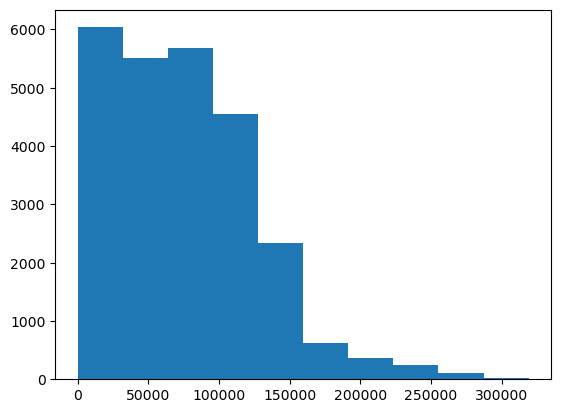

In [66]:
wage_data=visa_df['prevailing_wage']
plt.hist(wage_data)

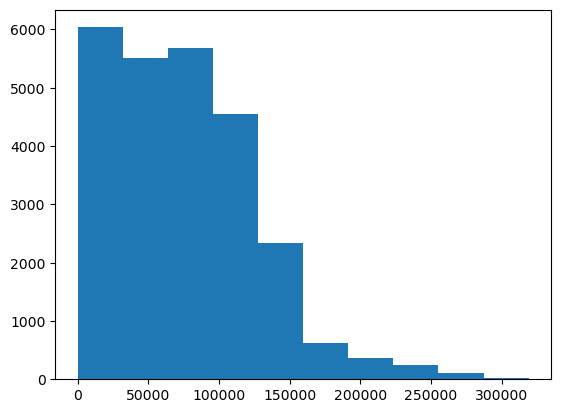

In [67]:
wage_data=visa_df['prevailing_wage']
plt.hist(wage_data)
plt.show()

**Box Plot**

            Q1-1.5IQR   Q1   median  Q3   Q3+1.5IQR
                       |-----:-----|
       o      |--------|     :     |--------|    o  o
                       |-----:-----|
     flier             <----------->            fliers
                            IQR


{'whiskers': [<matplotlib.lines.Line2D at 0x21090aa9e50>,
 'caps': [<matplotlib.lines.Line2D at 0x21090ac87d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x21090aa8410>],
 'medians': [<matplotlib.lines.Line2D at 0x21090ac8a50>],
 'fliers': [<matplotlib.lines.Line2D at 0x21090ac8b90>],
 'means': []}

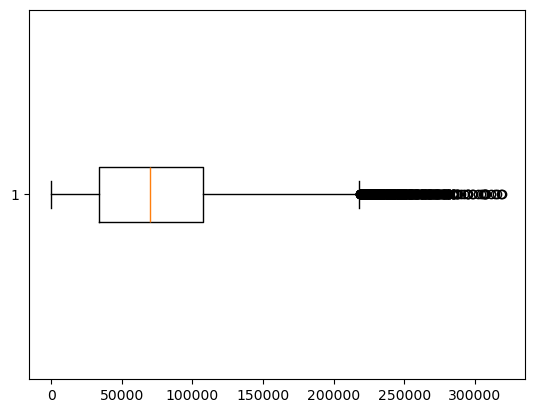

In [3]:
wage_data=visa_df['prevailing_wage']
plt.boxplot(wage_data,vert=False)

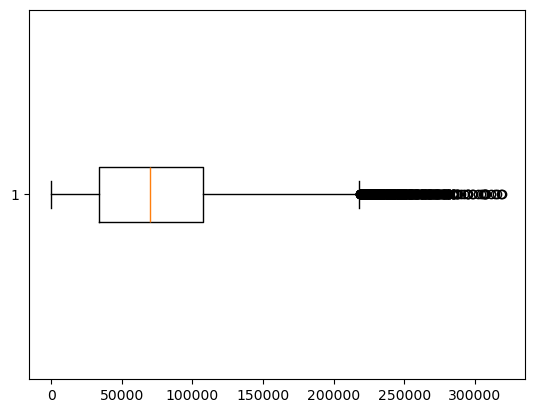

In [4]:
wage_data=visa_df['prevailing_wage']
plt.boxplot(wage_data,vert=False)
plt.show()

**How many outlier**

In [5]:
#step-1:q1
#step-2:q2
#step-3:q3
#step-4:IQR=q3-q1
#step-5:lb=q1-1.5*IQR
#step-6:ub=q3+1.5*IQR
#step-7:con1=wage_data<lb
#step-8:con2=wage-data>ub
#step-9:con=con1 con2
#step-10:numpy

In [4]:
# Step 1: Find Q1 (25th percentile)
q1 = np.percentile(wage_data, 25)

# Step 2: Find Q2 (Median)
q2 = np.percentile(wage_data, 50)

# Step 3: Find Q3 (75th percentile)
q3 = np.percentile(wage_data, 75)

# Step 4: Calculate IQR
IQR = q3 - q1

# Step 5: Calculate Lower Bound
lb = q1 - 1.5 * IQR

# Step 6: Calculate Upper Bound
ub = q3 + 1.5 * IQR

# Step 7: Condition for values below lower bound
con1 = wage_data < lb

# Step 8: Condition for values above upper bound
con2 = wage_data > ub

# Step 9: Combine both conditions
con = con1 | con2
np.sum(con)

np.int64(427)

In [8]:
visa_df[con]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
14,EZYV15,Asia,Master's,Y,Y,15756,2006,South,220081.73,Year,Y,Certified
34,EZYV35,Asia,Master's,N,N,1809,2010,South,225569.73,Year,N,Certified
130,EZYV131,South America,High School,N,N,2554,2005,Midwest,247393.01,Year,Y,Certified
216,EZYV217,Asia,Master's,Y,N,1515,2001,Midwest,269321.68,Year,N,Certified
221,EZYV222,North America,Doctorate,Y,Y,2518,2010,South,219529.62,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25191,EZYV25192,Asia,Master's,N,N,4983,2005,Midwest,280482.51,Year,Y,Denied
25195,EZYV25196,North America,Master's,Y,N,47,2001,South,234308.77,Year,N,Certified
25468,EZYV25469,Asia,Bachelor's,N,N,373,2005,Midwest,272715.74,Year,N,Certified
25469,EZYV25470,North America,Master's,Y,N,2261,1997,Northeast,273772.47,Year,N,Certified


In [5]:
wage_outliers=wage_data[con].values.tolist()
wage_outliers

[220081.73,
 225569.73,
 247393.01,
 269321.68,
 219529.62,
 232227.33,
 238691.32,
 220448.17,
 230750.48,
 235339.91,
 232680.65,
 256261.78,
 262189.0,
 250510.67,
 218554.78,
 256205.38,
 221944.22,
 229950.7,
 222628.84,
 229819.69,
 233641.72,
 274019.43,
 218982.83,
 230984.28,
 223128.23,
 246705.0,
 240266.34,
 226090.72,
 231949.27,
 254604.08,
 288318.91,
 244457.48,
 242146.48,
 247545.23,
 234139.17,
 231834.72,
 222730.57,
 239773.63,
 220553.95,
 237539.32,
 266440.49,
 277281.01,
 275627.59,
 249291.12,
 292106.59,
 234012.11,
 247009.24,
 267726.09,
 222098.09,
 280661.13,
 277984.52,
 262852.71,
 263877.21,
 230916.64,
 264760.64,
 267868.56,
 222221.67,
 242406.32,
 276894.08,
 281832.93,
 221033.57,
 258292.84,
 223492.85,
 245418.67,
 250289.08,
 271344.69,
 252825.11,
 230843.7,
 253668.86,
 245819.17,
 239465.3,
 236316.36,
 225268.13,
 228941.33,
 306021.96,
 228074.25,
 270799.93,
 221982.69,
 256903.7,
 242813.07,
 253111.05,
 268440.33,
 225681.78,
 233150.41

**Fill the outliers with median**

In [8]:
l=[]
for i in wage_data:
    if i in wage_outliers:
        l.append(q2)
    else:
        l.append(i)
visa_df['wage_q2']=l
print(visa_df['wage_q2'])

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476     70308.2100
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: wage_q2, Length: 25480, dtype: float64


**np.where**

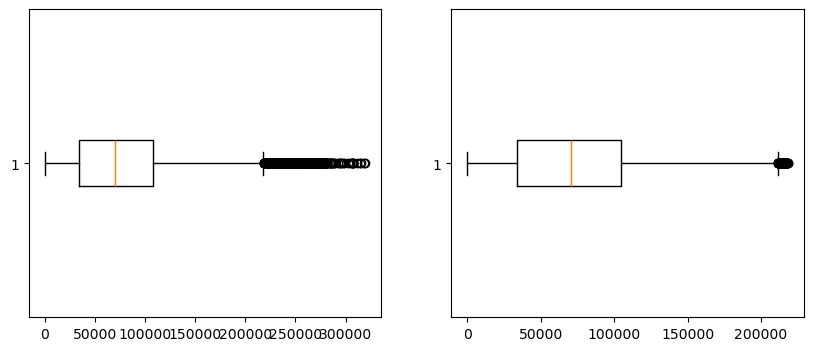

In [10]:
wage_data=visa_df['prevailing_wage']
wage_data_q2=visa_df['wage_q2']
plt.figure(figsize=(10,4))
plt.subplot(1,2,1).boxplot(wage_data,vert=False)
plt.subplot(1,2,2).boxplot(wage_data_q2,vert=False)
plt.show()

**Capping**
- we can fill the outliers which is less than 25p with 25pvalue
- we can fill the outlier which is less than 75p with 75pvalue

In [11]:
wage_data=visa_df['prevailing_wage']
q1 = np.percentile(wage_data, 25)
q2 = np.percentile(wage_data, 50)
q3 = np.percentile(wage_data, 75)
IQR = q3 - q1
lb = q1 - 1.5 * IQR
ub = q3 + 1.5 * IQR
visa_df['wage_data_cap']=wage_data.clip(lb,ub)

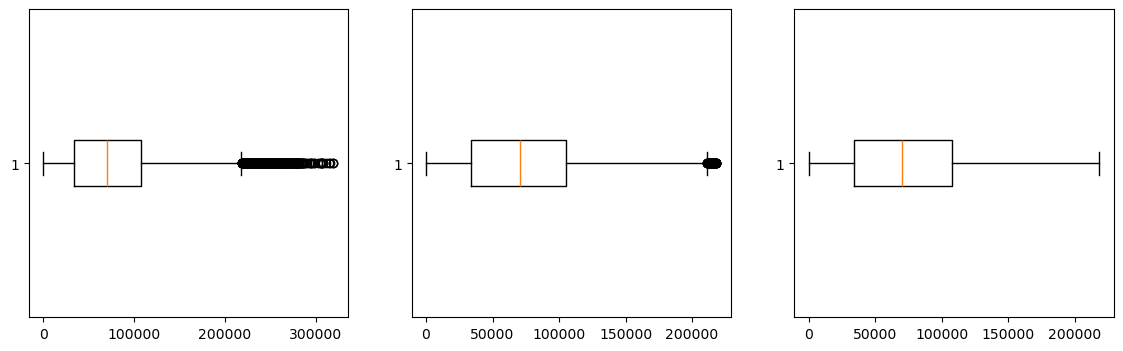

In [12]:
wage_data=visa_df['prevailing_wage']
wage_data_q2=visa_df['wage_q2']
wage_data_cap=visa_df['wage_data_cap']
plt.figure(figsize=(14,4))
plt.subplot(1,3,1).boxplot(wage_data,vert=False)
plt.subplot(1,3,2).boxplot(wage_data_q2,vert=False)
plt.subplot(1,3,3).boxplot(wage_data_cap,vert=False)
plt.show()

In [5]:
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [7]:
con1=visa_df['continent']=='Asia'
con2=visa_df['case_status']=='Certified'
certi_count=np.sum(con1&con2)
con3=visa_df['case_status']=='Denied'
denied_count=np.sum(con1&con3)
print(certi_count,denied_count)

11012 5849


In [8]:
table = pd.DataFrame(
    {'Certified': [certi_count],
     'Denied': [denied_count]},
    index=['Asia']
)

print(table)

      Certified  Denied
Asia      11012    5849


In [10]:
keys=visa_df['continent'].value_counts().keys()
clist,dlist=[],[]
for i in keys:
    con1=visa_df['continent']=='Asia'
    con2=visa_df['case_status']=='Certified'
    certi_count=np.sum(con1&con2)
    clist.append(certi_count)
    con3=visa_df['case_status']=='Denied'
    denied_count=np.sum(con1&con3)
    dlist.append(denied_count)
pd.DataFrame(zip(clist,dlist),columns=['Certified','Denied'],
             index=keys)

,Certified,Denied
continent,,
Asia,11012,5849
Europe,11012,5849
North America,11012,5849
South America,11012,5849
Africa,11012,5849
Oceania,11012,5849


**Crosstab**

In [11]:
col1=visa_df['case_status']
col2=visa_df['continent']
pd.crosstab(col1,col2)

continent,Africa,Asia,Europe,North America,Oceania,South America
case_status,,,,,,
Certified,397,11012,2957,2037,122,493
Denied,154,5849,775,1255,70,359


In [12]:
pd.crosstab(col2,col1)

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [15]:
col3=visa_df['education_of_employee']
pd.crosstab(col1,[col2,col3])

continent                 Africa                                      Asia  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
case_status                                                                  
Certified                     81        43          23      250       4407   
Denied                        62        11          43       38       2761   

continent                                                Europe            \
education_of_employee Doctorate High School Master's Bachelor's Doctorate   
case_status                                                                 
Certified                   780         676     5149       1040       788   
Denied                      143        1614     1331        259        58   

continent              ... North America             Oceania            \
education_of_employee  ...   High School Master's Bachelor's Doctorate   
case_status            ...                                               
Certified              ...           210      979         38        19   
Denied                 ...           191      429         28         3   

continent                                  South America            \
education_of_employee High School Master's    Bachelor's Doctorate   
case_status                                                          
Certified                      19       46           160        75   
Denied                         17       22           173        14   

continent                                   
education_of_employee High School Master's  
case_status                                 
Certified                      74      184  
Denied                         63      109  

[2 rows x 24 columns]

In [16]:
pd.crosstab(col2,[col1,col3])

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

In [17]:
pd.crosstab(col3,[col2,col1])

continent                Africa             Asia           Europe         \
case_status           Certified Denied Certified Denied Certified Denied   
education_of_employee                                                      
Bachelor's                   81     62      4407   2761      1040    259   
Doctorate                    43     11       780    143       788     58   
High School                  23     43       676   1614       162    328   
Master's                    250     38      5149   1331       967    130   

continent             North America          Oceania        South America  \
case_status               Certified Denied Certified Denied     Certified   
education_of_employee                                                       
Bachelor's                      641    584        38     28           160   
Doctorate                       207     51        19      3            75   
High School                     210    191        19     17            74   
Master's                        979    429        46     22           184   

continent                     
case_status           Denied  
education_of_employee         
Bachelor's               173  
Doctorate                 14  
High School               63  
Master's                 109

**Scatter Plot**

<Axes: xlabel='continent'>

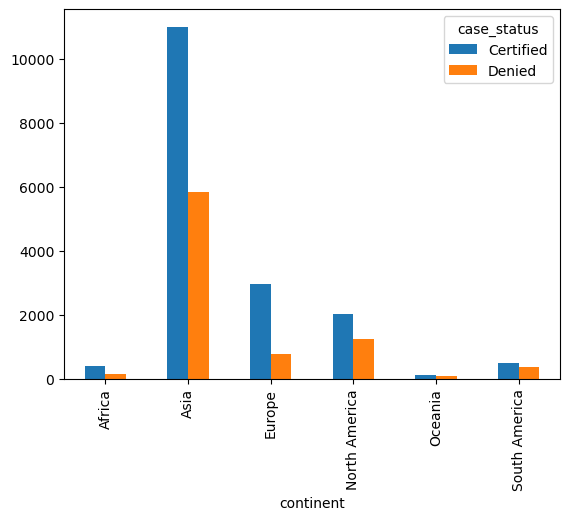

In [18]:
col1=visa_df['case_status']
col2=visa_df['continent']
r1=pd.crosstab(col2,col1)
r1.plot(kind='bar')

<Axes: xlabel='continent'>

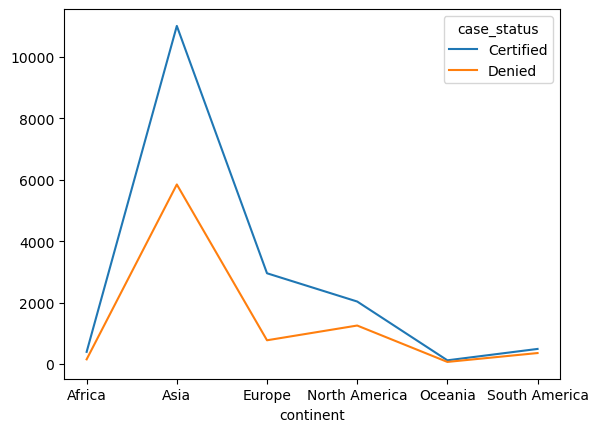

In [19]:
r1.plot()

- categorical : freq,bar charts,pie charts,relative
- numerical : histogram
- cat vs num : pd.cross tab analysis
- num vs num : corelation,covariance,scatterplot

**Scatter plots**

- it is a graph representation b/w two numerical columns
- it is also gives the relationship status b/w two columns
  - positive or negative or no relation

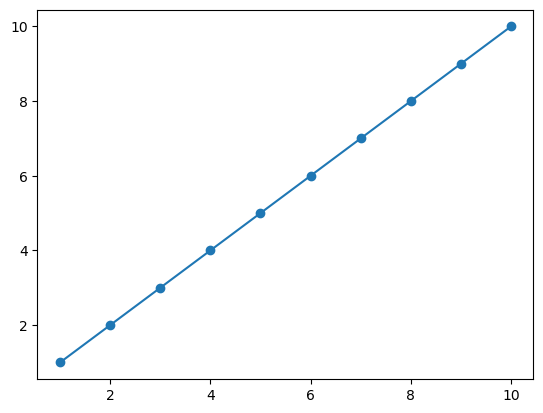

In [22]:
x=range(1,11)
y=range(1,11)
plt.scatter(x,y)
plt.plot(x,y)

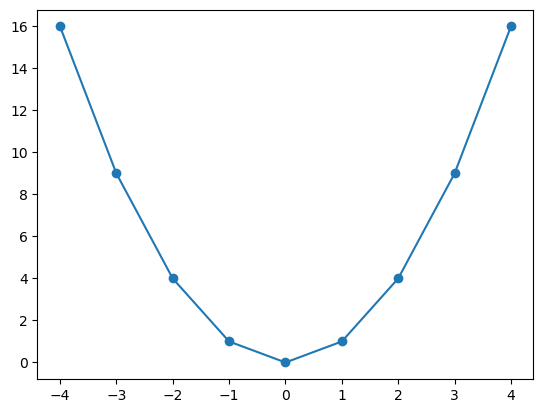

In [29]:
x=range(-4,5)
y=np.square(x)
plt.scatter(x,y)
plt.plot(x,y)

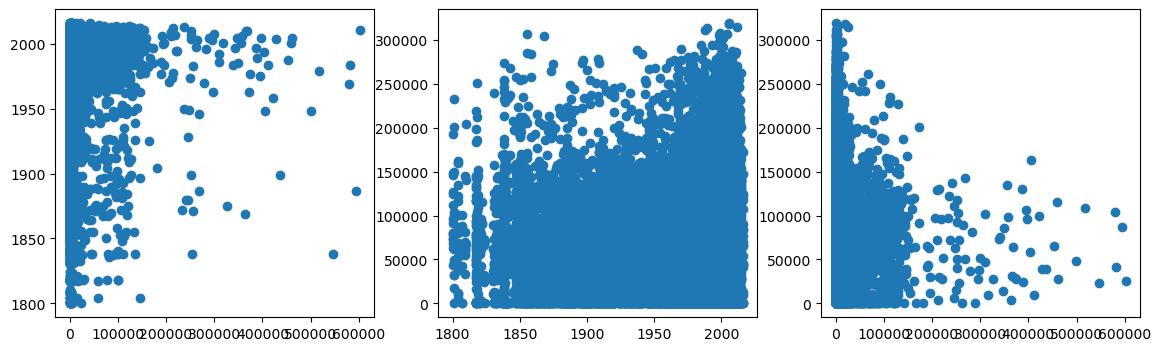

In [6]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(14,4))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col2,col3)
plt.subplot(1,3,3).scatter(col1,col3)

- we have draw the scatter plots for numerical columns
- by seeing above plots we are not able to identify the relationshipe accurateli
- to get more confident we will goto correlation matrix

In [7]:
visa_df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


In [ ]:
#1 indicates same column correlation == 100% relationship

In [8]:
#in your datafiles:winequality
#read the df
#perform the correlation matrix
#do you analysis yourself immediatelly which columns has high +ve -ve relation

In [9]:
wine_df=pd.read_csv(r"C:\Users\B VENKATA SAILAJA\Documents\Datasets_GenAi\winequality_red.csv")
wine_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [10]:
wine_df.corr(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


**heatmap**

- it is in seaborn package
- so far whatever the plots we did tha same we can implement by using the seaborn
- barchart,histgram,countplots,distribution,boxplot

<Axes: >

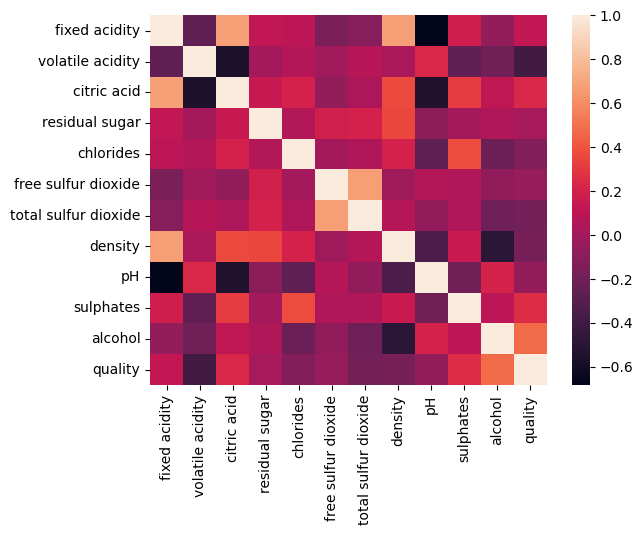

In [13]:
sns.heatmap(wine_df.corr())

<Axes: >

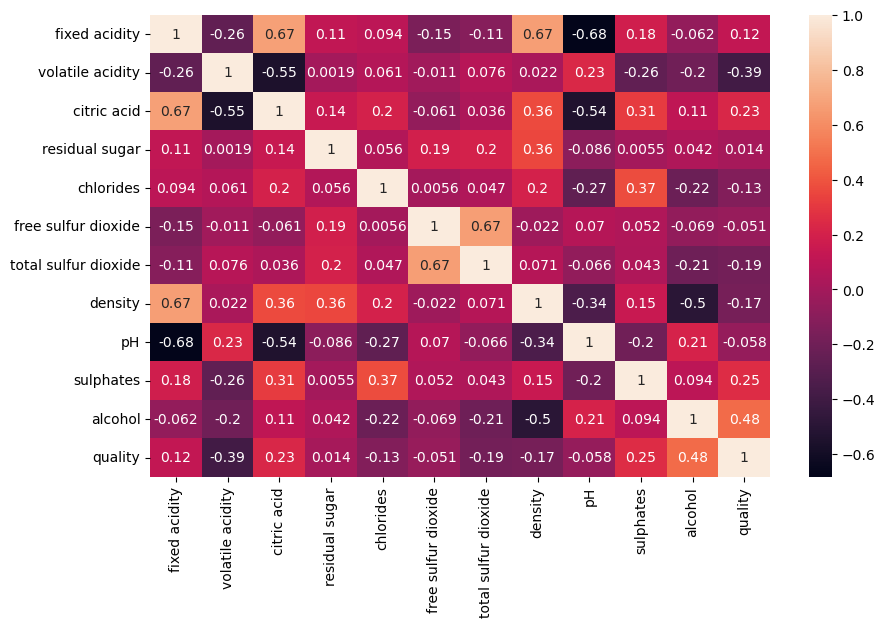

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(wine_df.corr(),
           annot=True)